# 🔧 Valve Plate Fault Prediction in Hydraulic Pumps
### Replication of the paper:
> **"A Dataset and a Comparison of Classification Methods for Valve Plate Fault Prediction of Piston Pump"**  
> Applied Sciences, 2024 — Rojek & Blachnik

---
## 📋 Notebook Steps:
1. Download the dataset
2. Exploratory Data Analysis (EDA)
3. Prepare data as described in the paper
4. Train all models compared in the paper
5. Evaluate and compare results
6. Feature importance analysis

# 🔧 Valve Plate Fault Prediction in Hydraulic Pumps
> **GitHub Version** - For local execution

### Setup Instructions
1. Clone this repository
2. Download the dataset from [Kaggle - Valve Plate Failure Prediction](https://www.kaggle.com/datasets/mbjunior/valve-plate-failure-prediction-in-hydraulic-pumps)
3. Extract CSV files to a `data/` folder
4. Install dependencies: `pip install -r requirements.txt`
5. Run this notebook: `jupyter notebook valve_plate_fault_prediction.ipynb`

---

### Paper Replication
> **"A Dataset and a Comparison of Classification Methods for Valve Plate Fault Prediction of Piston Pump"**  
> Rojek, M.; Blachnik, M. (2023)


## 📦 Step 1: Install Libraries & Load Data

In [ ]:
# pip install kaggle imbalanced-learn -q (Download from Kaggle manually)import osimport warningswarnings.filterwarnings('ignore')print('Libraries installed.')

Libraries installed.


In [ ]:
# --------------------------------------------------# Option A: Upload files manually from Kaggle# --------------------------------------------------# 1. Go to: https://www.kaggle.com/datasets/mbjunior/valve-plate-failure-prediction-in-hydraulic-pumps# 2. Click Download — you will get a .zip file# 3. Extract it — you will get 4 CSV files# 4. Upload them belowfrom google.colab import filesprint("📁 ارفع ملف kaggle.json")uploaded = files.upload()# إعداد المسارos.makedirs('/root/.config/kaggle', exist_ok=True)os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')os.chmod('/root/.config/kaggle/kaggle.json', 0o600)print('✅ تم إعداد Kaggle API')

📁 ارفع ملف kaggle.json


Saving kaggle.json to kaggle.json
✅ تم إعداد Kaggle API


In [ ]:
# تحميل البيانات من Kaggle# kaggle datasets download -d mbjunior/valve-plate-failure-prediction-in-hydraulic-pumps (Download from Kaggle manually)!unzip -q valve-plate-failure-prediction-in-hydraulic-pumps.zip -d data/!ls data/print('✅ تم تحميل البيانات')

Dataset URL: https://www.kaggle.com/datasets/mbjunior/valve-plate-failure-prediction-in-hydraulic-pumps
License(s): MIT
valve-plate-failure-prediction-in-hydraulic-pumps.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/dane_OT.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: dane_OT.csv  dane_UT1.csv  dane_UT2.csv  dane_UT3.csv  kaggle.json
✅ تم تحميل البيانات


## 📊 Step 2: Import Libraries & Read Data

In [ ]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.preprocessing import StandardScalerfrom sklearn.model_selection import StratifiedKFold, cross_val_scorefrom sklearn.neural_network import MLPClassifierfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifierfrom sklearn.neighbors import KNeighborsClassifierfrom sklearn.metrics import (    accuracy_score, classification_report,    confusion_matrix, ConfusionMatrixDisplay)from sklearn.inspection import permutation_importanceplt.rcParams.update({'font.size': 13, 'figure.dpi': 100})sns.set_theme(style='whitegrid')print('All libraries imported.')

All libraries imported.


In [ ]:
# --------------------------------------------------# Read the 4 CSV files# OT       = Normal operation# UT1/2/3  = 3 different fault severities# --------------------------------------------------file_names = {    'OT' : 'data/dane_OT.csv',    'UT1': 'data/dane_UT1.csv',    'UT2': 'data/dane_UT2.csv',    'UT3': 'data/dane_UT3.csv',}dfs = {}for name, path in file_names.items():    df = pd.read_csv(path)    df['Czas'] = pd.to_datetime(df['Czas'])    df.set_index('Czas', inplace=True)    dfs[name] = df    print(f"{name}: {df.shape[0]:,} rows | label values: {df['stan'].unique()}")print('\nColumns:', dfs['OT'].columns.tolist())

OT: 68,347 rows | label values: [0]
UT1: 54,053 rows | label values: [1]
UT2: 14,333 rows | label values: [1]
UT3: 16,472 rows | label values: [1]

Columns: ['Czas2', 'Pressure - leak line', 'Temperature - leak line', 'Pressure - output', 'Temperature - suction line', 'Temperature - output', 'Flow - leak line', 'Flow - output', 'Temp. diff', 'stan']


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [ ]:
# Summary statistics for normal operationprint('=== Normal Operation (OT) — Summary Statistics ===')print(dfs['OT'].describe().round(3))

=== Normal Operation (OT) — Summary Statistics ===
       Pressure - leak line  Temperature - leak line  Pressure - output  \
count             68347.000                68347.000          68347.000   
mean                  0.175                   48.107            128.234   
std                   0.041                    8.206             80.400   
min                   0.000                    0.000             -1.846   
25%                   0.144                   43.132             51.333   
50%                   0.174                   47.031            128.912   
75%                   0.200                   55.047            200.835   
max                   0.338                   63.755            294.052   

       Temperature - suction line  Temperature - output  Flow - leak line  \
count                   68347.000             68347.000         68347.000   
mean                       34.224                35.924             1.107   
std                         9.667         

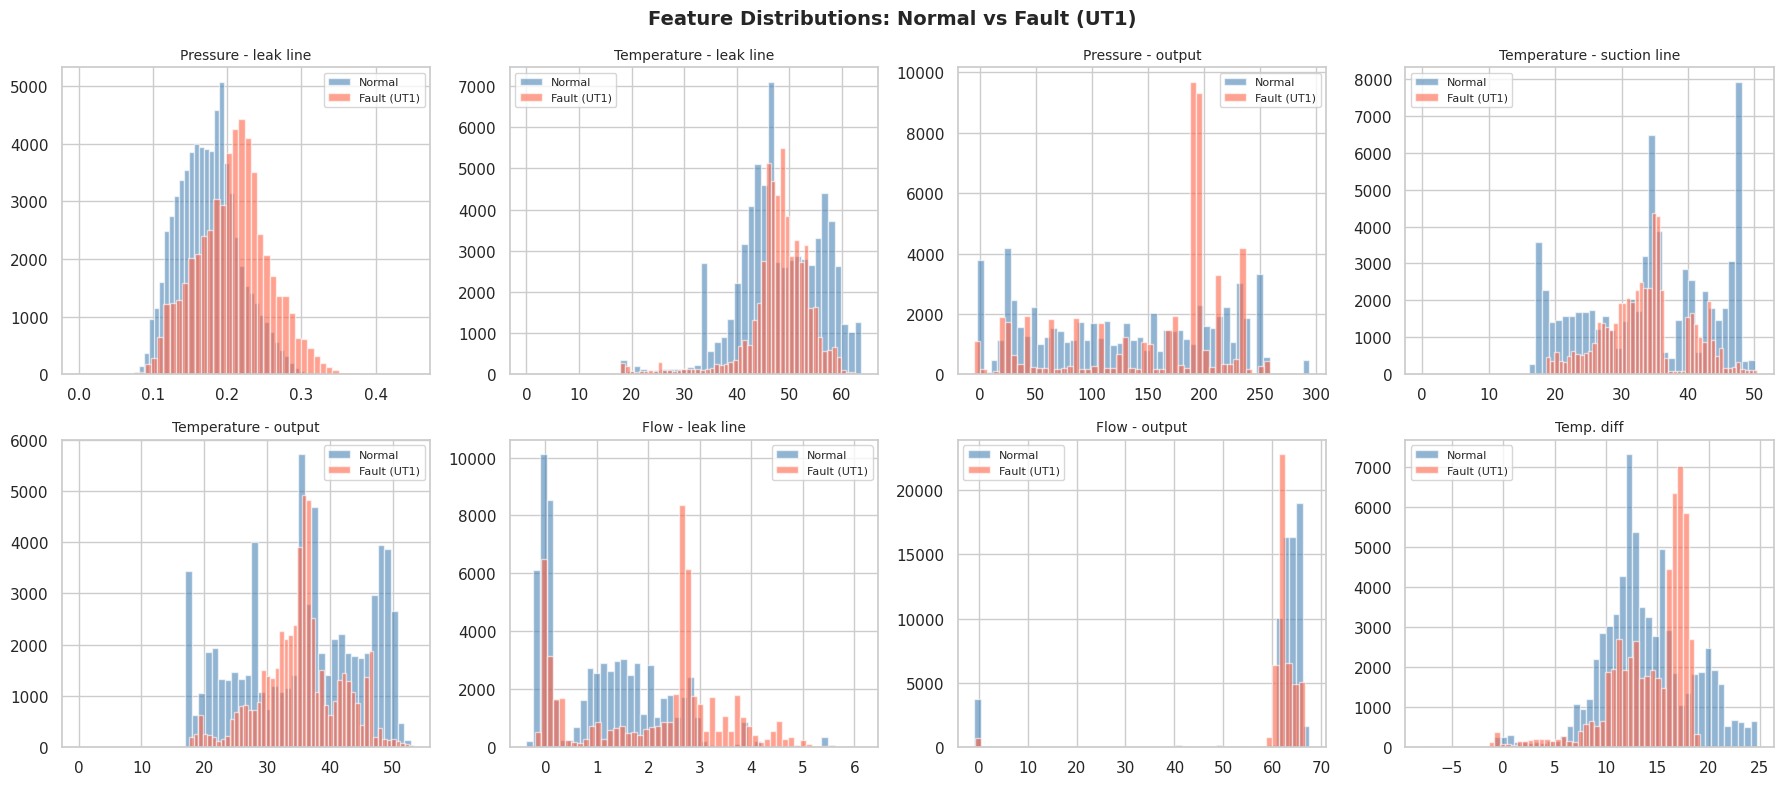

In [ ]:
# Feature columns used for classification (from the paper)cols_x = [    'Pressure - leak line',    'Temperature - leak line',    'Pressure - output',    'Temperature - suction line',    'Temperature - output',    'Flow - leak line',    'Flow - output',    'Temp. diff']# Distribution: Normal vs Faultfig, axes = plt.subplots(2, 4, figsize=(18, 8))axes = axes.flatten()for i, col in enumerate(cols_x):    axes[i].hist(dfs['OT'][col].dropna(),  bins=50, alpha=0.6, label='Normal', color='steelblue')    axes[i].hist(dfs['UT1'][col].dropna(), bins=50, alpha=0.6, label='Fault (UT1)', color='tomato')    axes[i].set_title(col, fontsize=10)    axes[i].legend(fontsize=8)plt.suptitle('Feature Distributions: Normal vs Fault (UT1)', fontsize=14, fontweight='bold')plt.tight_layout()plt.show()

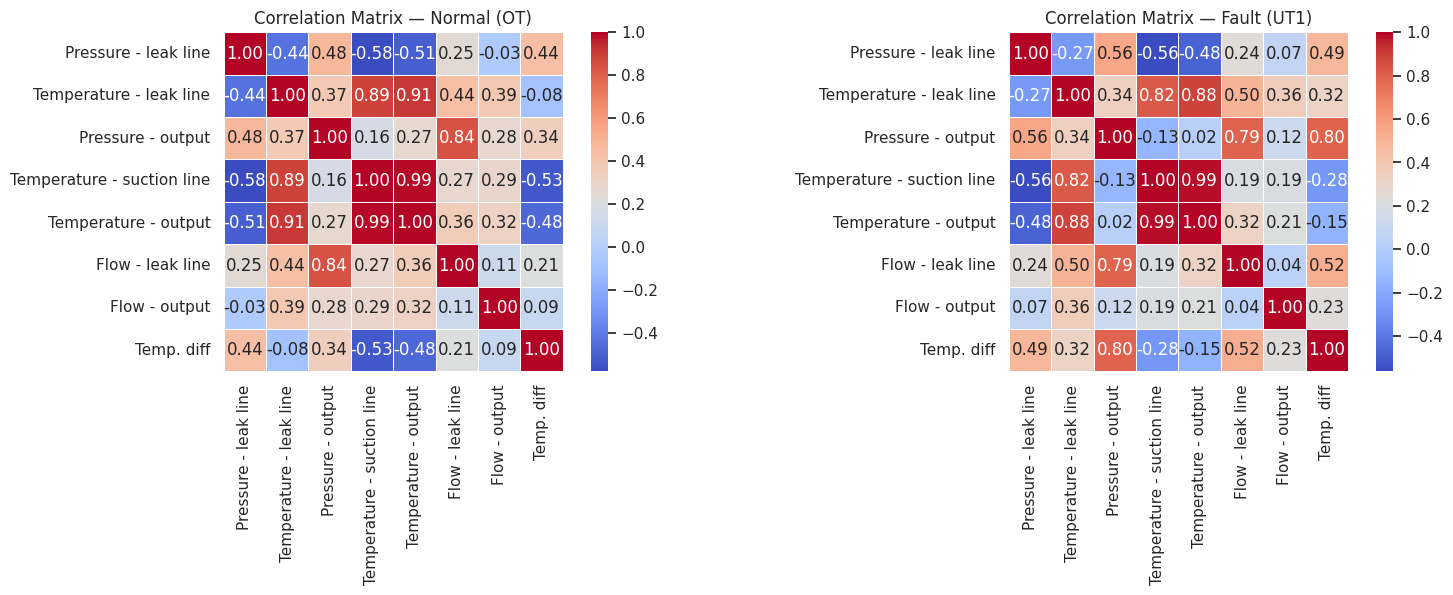

In [ ]:
# Correlation matricesfig, axes = plt.subplots(1, 2, figsize=(16, 6))for ax, (label, df) in zip(axes, [('Normal (OT)', dfs['OT']), ('Fault (UT1)', dfs['UT1'])]):    corr = df[cols_x].corr()    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',                ax=ax, cbar=True, square=True, linewidths=0.5)    ax.set_title(f'Correlation Matrix — {label}', fontsize=12)plt.tight_layout()plt.show()

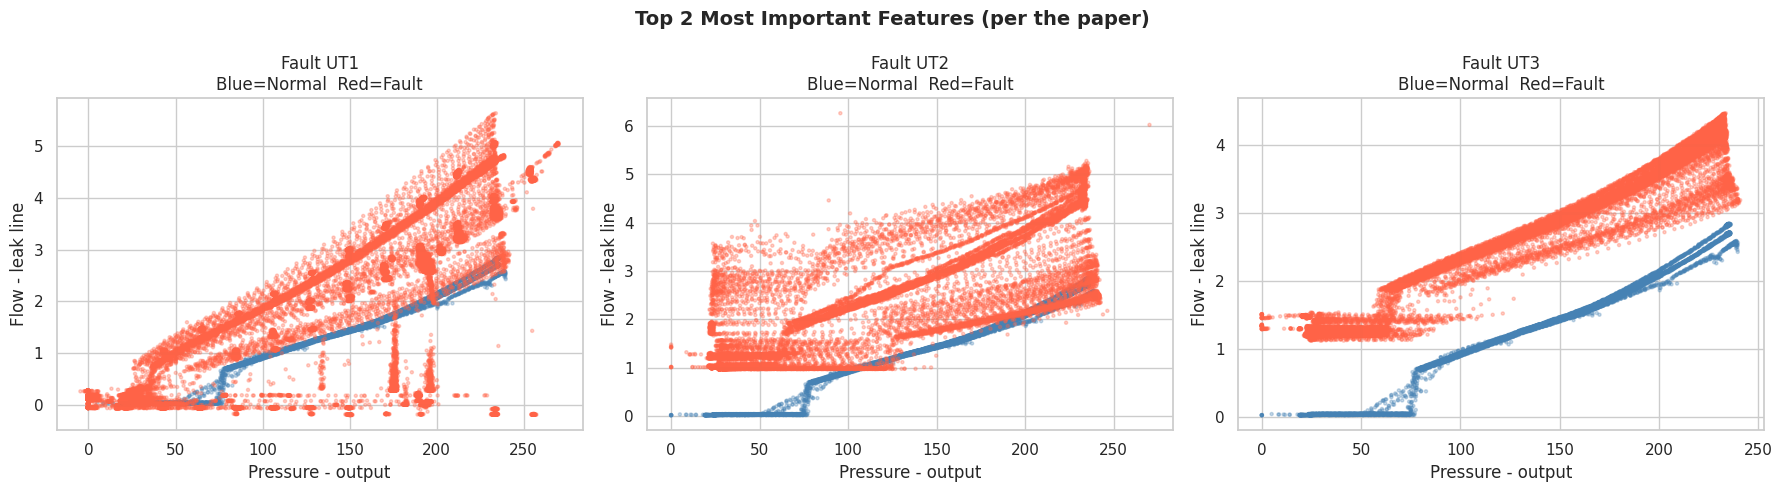

In [ ]:
# Scatter plot: Pressure-output vs Flow-leak (most important features per paper)fig, axes = plt.subplots(1, 3, figsize=(18, 5))for ax, key, title in zip(axes, ['UT1','UT2','UT3'], ['Fault UT1','Fault UT2','Fault UT3']):    combined = pd.concat([dfs['OT'].iloc[-5000:], dfs[key]], axis=0)    colors = combined['stan'].map({0: 'steelblue', 1: 'tomato'})    ax.scatter(combined['Pressure - output'], combined['Flow - leak line'],               c=colors, alpha=0.3, s=5)    ax.set_xlabel('Pressure - output')    ax.set_ylabel('Flow - leak line')    ax.set_title(f'{title}\nBlue=Normal  Red=Fault')plt.suptitle('Top 2 Most Important Features (per the paper)', fontsize=14, fontweight='bold')plt.tight_layout()plt.show()

## 🔧 Step 4: Data Preparation (as described in the paper)

### How the paper builds each dataset:
| Dataset | Contents | Purpose |
|---------|----------|---------|
| **UT1** | First part of OT (normal) + UT1 fault data | Training & Cross-Validation |
| **UT2** | Last 15,000 rows of OT + UT2 fault data | External test |
| **UT3** | Last 15,000 rows of OT + UT3 fault data | External test |

In [ ]:
col_y = 'stan'# Remove corrupted row (temperature = 0) as done in the paperdfs['OT'] = dfs['OT'].iloc[np.r_[0:2447, 2449:dfs['OT'].shape[0]]]# Build the 3 datasetsdata_UT1 = pd.concat([dfs['OT'].iloc[:-15000, :], dfs['UT1']], axis=0).dropna()data_UT2 = pd.concat([dfs['OT'].iloc[-15000:, :], dfs['UT2']], axis=0)data_UT3 = pd.concat([dfs['OT'].iloc[-15000:, :], dfs['UT3']], axis=0)for name, data in [('UT1', data_UT1), ('UT2', data_UT2), ('UT3', data_UT3)]:    total  = len(data)    normal = (data[col_y] == 0).sum()    fault  = (data[col_y] == 1).sum()    print(f"Dataset {name}: {total:,} rows | Normal: {normal:,} ({normal/total:.1%}) | Fault: {fault:,} ({fault/total:.1%})")print('\nData ready.')

Dataset UT1: 100,552 rows | Normal: 53,345 (53.1%) | Fault: 47,207 (46.9%)
Dataset UT2: 29,333 rows | Normal: 15,000 (51.1%) | Fault: 14,333 (48.9%)
Dataset UT3: 31,472 rows | Normal: 15,000 (47.7%) | Fault: 16,472 (52.3%)

Data ready.


In [ ]:
# Extract X and y, then scaleX_UT1 = data_UT1[cols_x].values;  y_UT1 = data_UT1[col_y].valuesX_UT2 = data_UT2[cols_x].values;  y_UT2 = data_UT2[col_y].valuesX_UT3 = data_UT3[cols_x].values;  y_UT3 = data_UT3[col_y].values# Fit scaler on UT1 only, then apply to UT2/UT3 (no data leakage)scaler = StandardScaler()X_UT1_scaled = scaler.fit_transform(X_UT1)X_UT2_scaled = scaler.transform(X_UT2)X_UT3_scaled = scaler.transform(X_UT3)print(f'X_UT1: {X_UT1_scaled.shape} | X_UT2: {X_UT2_scaled.shape} | X_UT3: {X_UT3_scaled.shape}')

X_UT1: (100552, 8) | X_UT2: (29333, 8) | X_UT3: (31472, 8)


## 🤖 Step 5: Train All Models

The paper compared these 4 classifiers:

| Model | Settings | Paper Result |
|-------|----------|--------------|
| **MLP** | layers=(100,10), lr=0.001 | **Best** ⭐ |
| Random Forest | n=100, depth=7, features=0.3 | Good |
| Gradient Boosting | n=100, depth=7, lr=0.1 | Good |
| KNN | k=201, weights=distance | Slightly lower |

In [ ]:
models = {    'MLP': MLPClassifier(        hidden_layer_sizes=(100, 10),        learning_rate_init=0.001,        max_iter=500,        random_state=42    ),    'Random Forest': RandomForestClassifier(        n_estimators=100, max_depth=7, max_features=0.3,        n_jobs=-1, random_state=42    ),    'Gradient Boosting': GradientBoostingClassifier(        n_estimators=100, max_depth=7, learning_rate=0.1,        random_state=42    ),    'KNN': KNeighborsClassifier(        n_neighbors=201, weights='distance', n_jobs=-1    )}print('Models defined.')

Models defined.


In [ ]:
# 10-Fold Stratified Cross-Validation on UT1 (as in the paper)cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)cv_results = {}print('Running 10-Fold Cross-Validation...\n')for name, model in models.items():    scores = cross_val_score(model, X_UT1_scaled, y_UT1,                             cv=cv, scoring='accuracy', n_jobs=-1)    cv_results[name] = scores    print(f'  {name}:')    print(f'    Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')    print(f'    Min: {scores.min():.4f}  Max: {scores.max():.4f}\n')print('Cross-Validation done.')

Running 10-Fold Cross-Validation...

  MLP:
    Accuracy: 0.9970 ± 0.0010
    Min: 0.9953  Max: 0.9983

  Random Forest:
    Accuracy: 0.9692 ± 0.0015
    Min: 0.9670  Max: 0.9714

  Gradient Boosting:
    Accuracy: 0.9991 ± 0.0003
    Min: 0.9985  Max: 0.9995

  KNN:
    Accuracy: 0.9817 ± 0.0012
    Min: 0.9796  Max: 0.9836

Cross-Validation done.


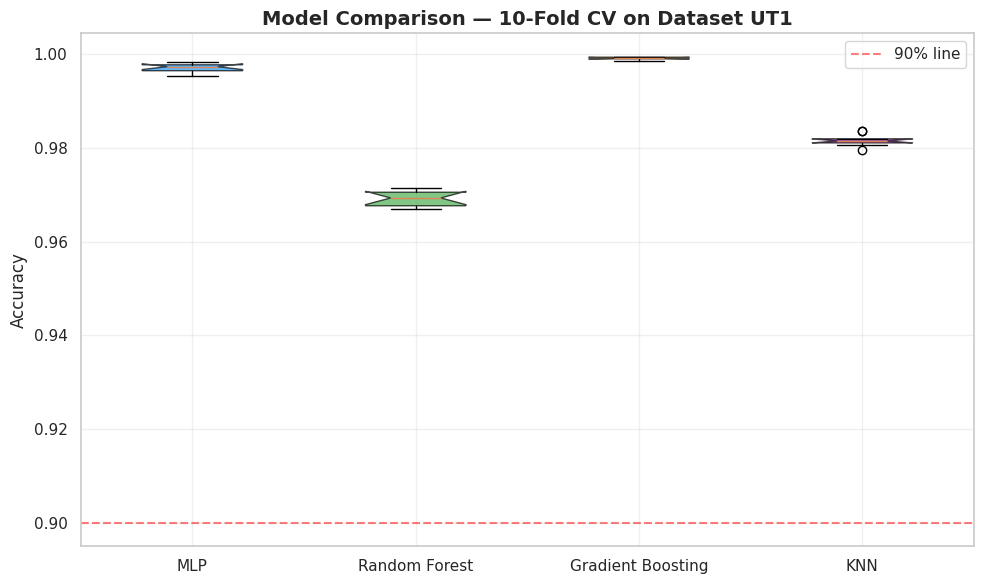


CV Results Summary:
            Model  Mean Acc      Std
Gradient Boosting  0.999105 0.000333
              MLP  0.997026 0.001003
              KNN  0.981651 0.001165
    Random Forest  0.969190 0.001545


In [ ]:
# Boxplot comparisonfig, ax = plt.subplots(figsize=(10, 6))data_plot = [cv_results[name] for name in models]labels    = list(models.keys())bp = ax.boxplot(data_plot, labels=labels, patch_artist=True, notch=True)colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']for patch, color in zip(bp['boxes'], colors):    patch.set_facecolor(color)    patch.set_alpha(0.7)ax.set_ylabel('Accuracy')ax.set_title('Model Comparison — 10-Fold CV on Dataset UT1', fontsize=14, fontweight='bold')ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% line')ax.legend()ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()# Summary tablesummary = pd.DataFrame({    'Model'   : labels,    'Mean Acc': [cv_results[n].mean() for n in models],    'Std'     : [cv_results[n].std()  for n in models],}).sort_values('Mean Acc', ascending=False)print('\nCV Results Summary:')print(summary.to_string(index=False))

## 🧪 Step 6: External Test on UT2 and UT3
The key generalization test — train on UT1, test on unseen fault types.

In [ ]:
# Train best model (MLP) on full UT1, test on UT2 and UT3best_model = MLPClassifier(    hidden_layer_sizes=(100, 10),    learning_rate_init=0.001,    max_iter=500,    random_state=42)best_model.fit(X_UT1_scaled, y_UT1)print('=== External Test Results ===')for name, X_test, y_test in [('UT2', X_UT2_scaled, y_UT2), ('UT3', X_UT3_scaled, y_UT3)]:    y_pred = best_model.predict(X_test)    acc = accuracy_score(y_test, y_pred)    print(f'\nDataset {name}:  Accuracy = {acc:.4f} ({acc:.2%})')    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fault']))

=== External Test Results ===

Dataset UT2:  Accuracy = 0.7704 (77.04%)
              precision    recall  f1-score   support

      Normal       0.74      0.85      0.79     15000
       Fault       0.81      0.69      0.75     14333

    accuracy                           0.77     29333
   macro avg       0.78      0.77      0.77     29333
weighted avg       0.78      0.77      0.77     29333


Dataset UT3:  Accuracy = 0.9119 (91.19%)
              precision    recall  f1-score   support

      Normal       0.96      0.85      0.90     15000
       Fault       0.88      0.97      0.92     16472

    accuracy                           0.91     31472
   macro avg       0.92      0.91      0.91     31472
weighted avg       0.92      0.91      0.91     31472



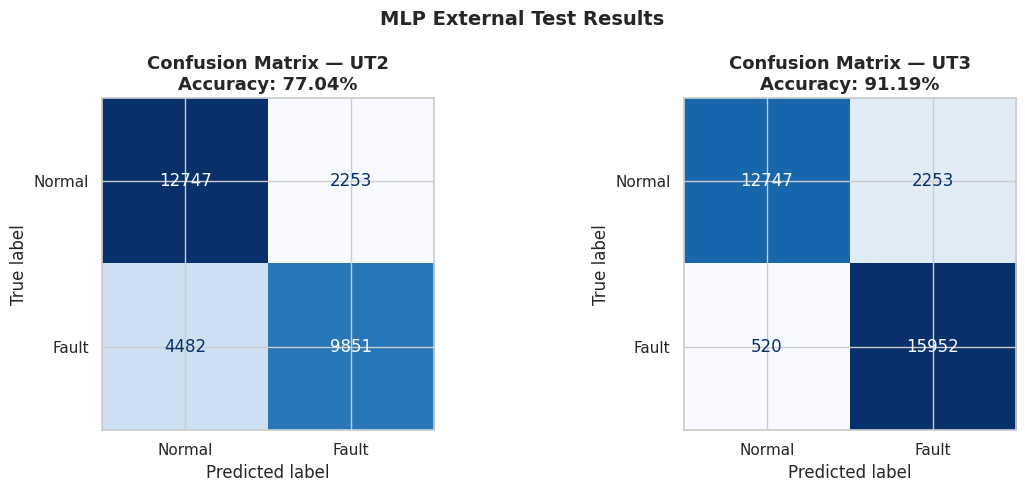

In [ ]:
# Confusion matricesfig, axes = plt.subplots(1, 2, figsize=(12, 5))for ax, (name, X_test, y_test) in zip(axes,    [('UT2', X_UT2_scaled, y_UT2), ('UT3', X_UT3_scaled, y_UT3)]):    y_pred = best_model.predict(X_test)    cm = confusion_matrix(y_test, y_pred)    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fault'])    disp.plot(ax=ax, colorbar=False, cmap='Blues')    ax.set_title(f'Confusion Matrix — {name}\nAccuracy: {accuracy_score(y_test, y_pred):.2%}',                 fontsize=13, fontweight='bold')plt.suptitle('MLP External Test Results', fontsize=14, fontweight='bold')plt.tight_layout()plt.show()

## 📈 Step 7: Feature Importance (Permutation)

Computing feature importances...


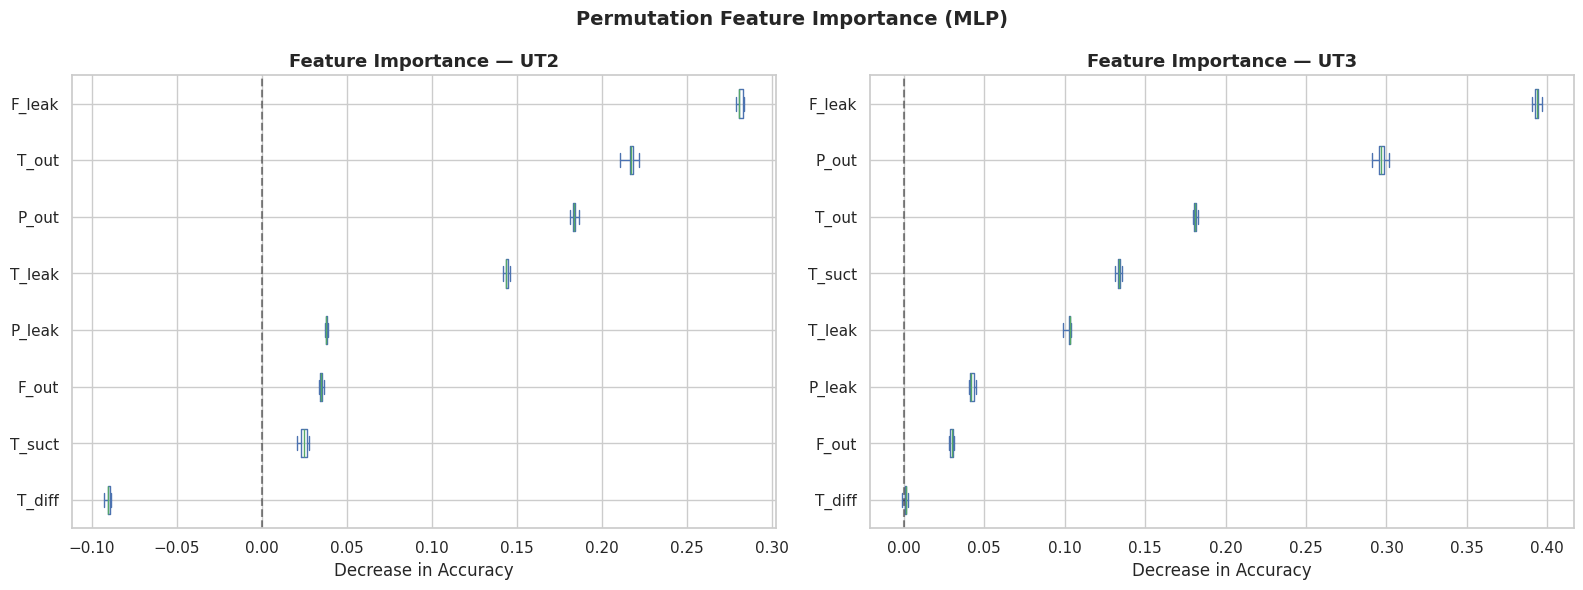


Higher value = more important for fault detection.


In [ ]:
# Permutation importance — as used in the paperprint('Computing feature importances...')feat_labels = {    'Pressure - leak line'      : 'P_leak',    'Temperature - leak line'   : 'T_leak',    'Pressure - output'         : 'P_out',    'Temperature - suction line': 'T_suct',    'Temperature - output'      : 'T_out',    'Flow - leak line'          : 'F_leak',    'Flow - output'             : 'F_out',    'Temp. diff'                : 'T_diff',}fig, axes = plt.subplots(1, 2, figsize=(16, 6))for ax, (name, X_test, y_test) in zip(axes,    [('UT2', X_UT2_scaled, y_UT2), ('UT3', X_UT3_scaled, y_UT3)]):    result = permutation_importance(        best_model, X_test, y_test,        n_repeats=10, random_state=42,        scoring='accuracy', n_jobs=-1    )    sorted_idx = result.importances_mean.argsort()    imp_df = pd.DataFrame(        result.importances[sorted_idx].T,        columns=[feat_labels[cols_x[i]] for i in sorted_idx]    )    imp_df.plot.box(vert=False, whis=10, ax=ax)    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)    ax.set_xlabel('Decrease in Accuracy')    ax.set_title(f'Feature Importance — {name}', fontsize=13, fontweight='bold')plt.suptitle('Permutation Feature Importance (MLP)', fontsize=14, fontweight='bold')plt.tight_layout()plt.show()print('\nHigher value = more important for fault detection.')

## 🔊 Step 8: Noise Robustness Test
How does the model perform when sensor readings contain noise?

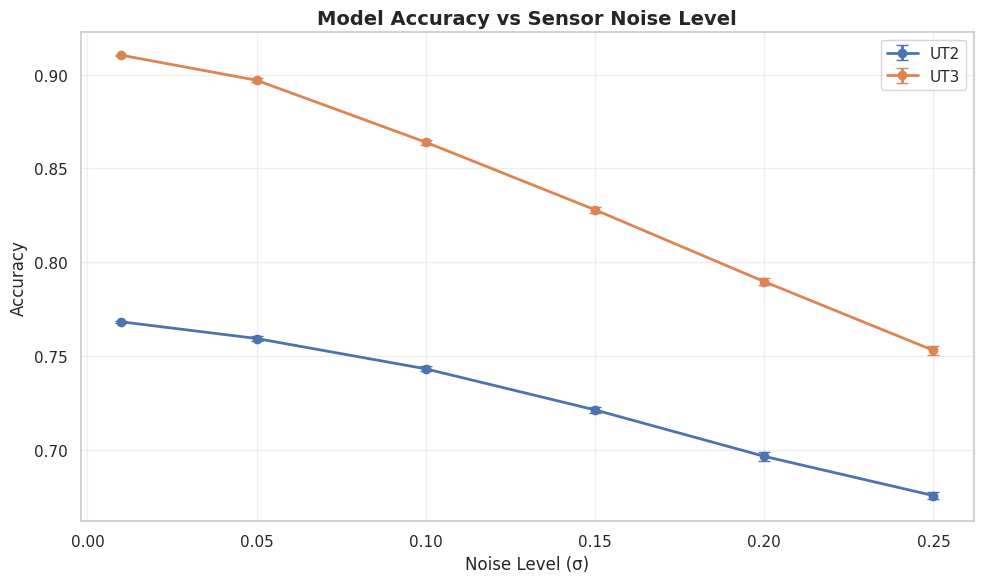

In [ ]:
noise_levels = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]n_repeats    = 20noise_results = {}for ds_name, X_test, y_test in [('UT2', X_UT2_scaled, y_UT2), ('UT3', X_UT3_scaled, y_UT3)]:    accs_mean, accs_std = [], []    for std in noise_levels:        trial_accs = []        for _ in range(n_repeats):            X_noisy = X_test + np.random.randn(*X_test.shape) * std            trial_accs.append(accuracy_score(y_test, best_model.predict(X_noisy)))        accs_mean.append(np.mean(trial_accs))        accs_std.append(np.std(trial_accs))    noise_results[ds_name] = (accs_mean, accs_std)plt.figure(figsize=(10, 6))for ds_name, (means, stds) in noise_results.items():    plt.errorbar(noise_levels, means, yerr=stds,                 label=ds_name, marker='o', capsize=4, linewidth=2)plt.xlabel('Noise Level (σ)')plt.ylabel('Accuracy')plt.title('Model Accuracy vs Sensor Noise Level', fontsize=14, fontweight='bold')plt.legend()plt.grid(True, alpha=0.3)plt.tight_layout()plt.show()

## ✅ Step 9: Final Results Summary

In [ ]:
print('=' * 65)print('              FINAL RESULTS SUMMARY')print('=' * 65)print(f"{'Model':<22} {'CV (UT1)':<22} {'UT2':<10} {'UT3'}")print('-' * 65)for name, model in models.items():    cv_mean = cv_results[name].mean()    cv_std  = cv_results[name].std()    model.fit(X_UT1_scaled, y_UT1)    acc_ut2 = accuracy_score(y_UT2, model.predict(X_UT2_scaled))    acc_ut3 = accuracy_score(y_UT3, model.predict(X_UT3_scaled))    star = ' ⭐' if name == 'MLP' else ''    print(f"{name:<22} {cv_mean:.4f} ± {cv_std:.4f}   {acc_ut2:.4f}    {acc_ut3:.4f}{star}")print('=' * 65)print('\nKey findings from the paper:')print('  Best model  : MLP — hidden_layers=(100, 10)')print('  Top features: Flow - leak line  &  Pressure - output')print('  Evaluation  : 10-Fold Stratified Cross-Validation')print('  Main challenge: class imbalance between Normal and Fault')

              FINAL RESULTS SUMMARY
Model                  CV (UT1)               UT2        UT3
-----------------------------------------------------------------
MLP                    0.9970 ± 0.0010   0.7704    0.9119 ⭐
Random Forest          0.9692 ± 0.0015   0.5544    0.7044
Gradient Boosting      0.9991 ± 0.0003   0.8197    0.9312
KNN                    0.9817 ± 0.0012   0.6026    0.7496

Key findings from the paper:
  Best model  : MLP — hidden_layers=(100, 10)
  Top features: Flow - leak line  &  Pressure - output
  Evaluation  : 10-Fold Stratified Cross-Validation
  Main challenge: class imbalance between Normal and Fault


In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_scoreprint('=' * 65)print(' FINAL RESULTS SUMMARY')print('=' * 65)print(f"{'Model':<20} {'CV Acc':<12} {'UT2 F1':<10} {'UT2 Acc':<10} {'UT3 Acc':<10}")print('-' * 65)# Store predictions for detailed analysis laterdetailed_results = {}for name, model in models.items():    cv_mean = cv_results[name].mean()    cv_std = cv_results[name].std()    # Fit and predict on all sets    model.fit(X_UT1_scaled, y_UT1)    y_pred_ut2 = model.predict(X_UT2_scaled)    y_pred_ut3 = model.predict(X_UT3_scaled)    # Calculate metrics    acc_ut2 = accuracy_score(y_UT2, y_pred_ut2)    acc_ut3 = accuracy_score(y_UT3, y_pred_ut3)    f1_ut2 = f1_score(y_UT2, y_pred_ut2, average='weighted', zero_division=0)    # Store for classification report    detailed_results[name] = {        'UT2': (y_UT2, y_pred_ut2),        'UT3': (y_UT3, y_pred_ut3)    }    star = ' ⭐' if name == 'MLP' else ''    print(f"{name:<20} {cv_mean:.4f}±{cv_std:.4f} {f1_ut2:<10.4f} {acc_ut2:<10.4f} {acc_ut3:<10.4f}{star}")print('=' * 65)# Detailed Classification Reports for Best Model (MLP)print('\n' + '=' * 65)print(' DETAILED CLASSIFICATION REPORT: MLP (Best Model)')print('=' * 65)for dataset in ['UT2', 'UT3']:    y_true, y_pred = detailed_results['MLP'][dataset]    print(f"\n>>> {dataset} - Per-Class Performance <<<")    print(classification_report(        y_true, y_pred,        target_names=['Normal', 'Fault'],        digits=4,        zero_division=0    ))    # Additional confusion matrix stats    from sklearn.metrics import confusion_matrix    cm = confusion_matrix(y_true, y_pred)    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)    print(f"Confusion Matrix [{dataset}]:")    print(f"                 Pred Normal  Pred Fault")    print(f"True Normal    {tn:>6}      {fp:>6}")    print(f"True Fault     {fn:>6}      {tp:>6}")    print(f"Recall (Fault): {tp/(tp+fn):.4f}" if (tp+fn) > 0 else "N/A")print('\n' + '=' * 65)print('Key findings from the paper:')print(' Best model    : MLP — hidden_layers=(100, 10)')print(' Top features  : Flow - leak line & Pressure - output')print(' Evaluation    : 10-Fold Stratified Cross-Validation')print(' Class balance : Normal vs Fault (check support values above)')print('=' * 65)

 FINAL RESULTS SUMMARY
Model                CV Acc       UT2 F1     UT2 Acc    UT3 Acc   
-----------------------------------------------------------------
MLP                  0.9970±0.0010 0.7687     0.7704     0.9119     ⭐
Random Forest        0.9692±0.0015 0.5544     0.5544     0.7044    
Gradient Boosting    0.9991±0.0003 0.8191     0.8197     0.9312    
KNN                  0.9817±0.0012 0.6023     0.6026     0.7496    

 DETAILED CLASSIFICATION REPORT: MLP (Best Model)

>>> UT2 - Per-Class Performance <<<
              precision    recall  f1-score   support

      Normal     0.7399    0.8498    0.7910     15000
       Fault     0.8139    0.6873    0.7452     14333

    accuracy                         0.7704     29333
   macro avg     0.7769    0.7685    0.7681     29333
weighted avg     0.7760    0.7704    0.7687     29333

Confusion Matrix [UT2]:
                 Pred Normal  Pred Fault
True Normal     12747        2253
True Fault       4482        9851
Recall (Fault): 0.6873

---
## 📚 References
- Rojek, M.; Blachnik, M. *A Dataset and a Comparison of Classification Methods for Valve Plate Fault Prediction of Piston Pump.* **Applied Sciences** 2024, 14(16), 7183. https://doi.org/10.3390/app14167183
- Dataset: https://www.kaggle.com/datasets/mbjunior/valve-plate-failure-prediction-in-hydraulic-pumps
- Original code: https://github.com/mblachnik/2024_Valve_plate_failures